<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres
## Julia Stephania Maldonado a2319

### Corpus: *Dracula*, de Bram Stoker (Project Gutenberg) — mismo corpus reutilizado del Desafío 2

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [1]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy

### Datos

Reutilizamos el mismo corpus que en el Desafío 2 (*Dracula*, de Bram Stoker, texto completo en inglés, Project Gutenberg), tal como pide la consigna. A diferencia del Desafío 2 (embeddings con Word2Vec, tokenización por palabras), acá el modelo de lenguaje tokeniza por **caracteres**, por lo que no reutilizamos los embeddings de Gensim entrenados en ese desafío (esos vectores son por palabra, no por carácter) — reutilizamos únicamente el **dataset** (el texto del libro).

In [2]:
import os
import re

# Descargar el texto completo de Dracula (mismo corpus que en el Desafío 2), desde Project Gutenberg
if not os.path.exists("dracula.txt"):
    !wget -q "https://www.gutenberg.org/cache/epub/345/pg345.txt" -O dracula.txt
    print("Descarga completa")
else:
    print("El archivo ya se encuentra descargado")

Descarga completa


In [3]:
with open("dracula.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

# Project Gutenberg agrega licencia/metadata al principio y al final que no es parte de la novela;
# la removemos quedándonos solo con el texto entre los marcadores START/END (igual que en el Desafío 2)
start_match = re.search(r"\*\*\*\s*START OF (THE|THIS) PROJECT GUTENBERG EBOOK.*?\*\*\*", raw_text, re.IGNORECASE | re.DOTALL)
end_match = re.search(r"\*\*\*\s*END OF (THE|THIS) PROJECT GUTENBERG EBOOK.*?\*\*\*", raw_text, re.IGNORECASE | re.DOTALL)

book_text = raw_text[start_match.end():end_match.start()]

# Normalizamos saltos de línea simples (que Gutenberg usa para "cortar" renglones dentro de un mismo
# párrafo), reemplazándolos por un espacio para no partir oraciones a la mitad
book_text = re.sub(r"\r\n", "\n", book_text)
book_text = re.sub(r"(?<!\n)\n(?!\n)", " ", book_text)
book_text = re.sub(r"\s+", " ", book_text).strip()

# pasamos todo el texto a minúscula, igual que en el modelo de ejemplo
article_text = book_text.lower()

print("Cantidad de caracteres de la novela:", len(article_text))

Cantidad de caracteres de la novela: 838345


### Controlar el tamaño del corpus (para no quedarse sin RAM en Colab)

El libro completo tiene varios cientos de miles de caracteres. Al armar el dataset con ventana deslizante (más adelante), esto genera cientos de miles de secuencias muy solapadas entre sí, lo que puede agotar la RAM disponible en Colab (sobre todo en el entorno gratuito). Si eso pasa, se puede achicar el corpus con `max_chars` (por ejemplo, usando solo los primeros capítulos).

In [4]:
# Si Colab se queda sin RAM, bajar este valor (por ejemplo a 200000 o 100000).
# None = usar el libro completo.
max_chars = None

if max_chars is not None:
    article_text = article_text[:max_chars]

print(f'Cantidad de caracteres a utilizar: {len(article_text)}')

Cantidad de caracteres a utilizar: 838345


In [5]:
# en article_text se encuentra el texto completo del libro
article_text[:1000]

'dracula _by_ bram stoker [illustration: colophon] new york grosset & dunlap _publishers_ copyright, 1897, in the united states of america, according to act of congress, by bram stoker [_all rights reserved._] printed in the united states at the country life press, garden city, n.y. to my dear friend hommy-beg contents chapter i. jonathan harker’s journal chapter ii. jonathan harker’s journal chapter iii. jonathan harker’s journal chapter iv. jonathan harker’s journal chapter v. letters—lucy and mina chapter vi. mina murray’s journal chapter vii. cutting from “the dailygraph,” 8 august chapter viii. mina murray’s journal chapter ix. mina murray’s journal chapter x. mina murray’s journal chapter xi. lucy westenra’s diary chapter xii. dr. seward’s diary chapter xiii. dr. seward’s diary chapter xiv. mina harker’s journal chapter xv. dr. seward’s diary chapter xvi. dr. seward’s diary chapter xvii. dr. seward’s diary chapter xviii. dr. seward’s diary chapter xix. jonathan harker’s journal c

### Elegir el tamaño del contexto

En este caso, como el modelo de lenguaje es por caracteres, todo un gran corpus
de texto puede ser considerado un documento en sí mismo y el tamaño de contexto
puede ser elegido con más libertad en comparación a un modelo de lenguaje tokenizado por palabras y dividido en documentos más acotados.

### Análisis exploratorio para elegir el tamaño de contexto

Antes de fijar el tamaño de contexto (`max_context_size`), realizamos un análisis exploratorio de la longitud de las oraciones del corpus (medida en cantidad de caracteres). Esto permite elegir un tamaño de contexto que capture la mayor parte de las relaciones sintácticas dentro de una oración típica, sin ser excesivamente largo (mayor costo computacional y más padding innecesario) ni demasiado corto (limita la capacidad del modelo de aprender dependencias de largo alcance).

Cantidad de oraciones: 9331
Longitud promedio: 88.0 caracteres
Longitud mediana: 76.0 caracteres
Percentil 90: 175 caracteres
Percentil 95: 210 caracteres


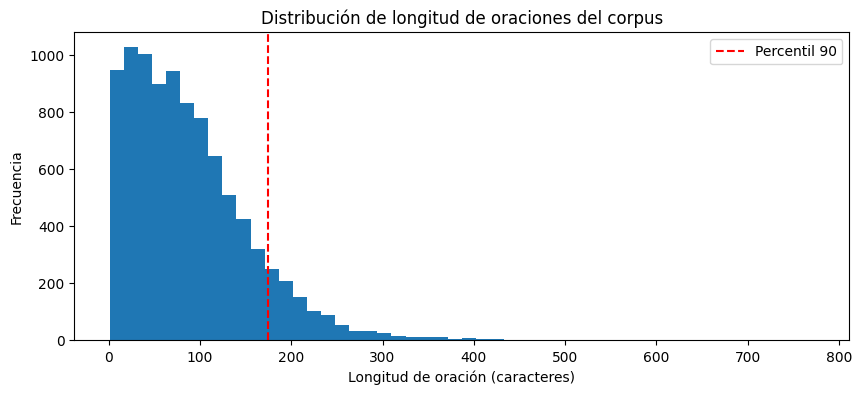

In [6]:
import re

# separamos el corpus en oraciones usando signos de puntuación como delimitador
sentences = re.split(r'[.!?]+', article_text)
sentences = [s.strip() for s in sentences if len(s.strip()) > 0]

sentence_lengths = [len(s) for s in sentences]

print(f'Cantidad de oraciones: {len(sentences)}')
print(f'Longitud promedio: {np.mean(sentence_lengths):.1f} caracteres')
print(f'Longitud mediana: {np.median(sentence_lengths):.1f} caracteres')
print(f'Percentil 90: {np.percentile(sentence_lengths, 90):.0f} caracteres')
print(f'Percentil 95: {np.percentile(sentence_lengths, 95):.0f} caracteres')

plt.figure(figsize=(10, 4))
plt.hist(sentence_lengths, bins=50)
plt.axvline(np.percentile(sentence_lengths, 90), color='r', linestyle='--', label='Percentil 90')
plt.xlabel('Longitud de oración (caracteres)')
plt.ylabel('Frecuencia')
plt.title('Distribución de longitud de oraciones del corpus')
plt.legend()
plt.show()

In [7]:
# el corpus tiene percentil 90 de longitud de oración = 175 caracteres, pero para no
# aumentar demasiado el costo computacional se eligió un valor más cercano al promedio (88)
# y la mediana (76), priorizando eficiencia por sobre cubrir el 90% de las oraciones completas
max_context_size = 100

In [9]:
# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
from tensorflow.keras.utils import pad_sequences # se utilizará para padding

In [10]:
# en este caso el vocabulario es el conjunto único de caracteres que existe en todo el texto
chars_vocab = set(article_text)

In [11]:
# la longitud de vocabulario de caracteres es:
len(chars_vocab)

69

In [12]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

###  Tokenizar

In [13]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]

In [14]:
tokenized_text[:1000]

[4,
 8,
 31,
 0,
 24,
 7,
 31,
 59,
 68,
 38,
 29,
 68,
 59,
 38,
 8,
 31,
 11,
 59,
 18,
 48,
 62,
 12,
 44,
 8,
 59,
 15,
 58,
 7,
 7,
 24,
 18,
 48,
 8,
 31,
 48,
 58,
 62,
 33,
 46,
 59,
 0,
 62,
 7,
 62,
 39,
 23,
 62,
 33,
 19,
 59,
 33,
 44,
 25,
 59,
 29,
 62,
 8,
 12,
 59,
 3,
 8,
 62,
 18,
 18,
 44,
 48,
 59,
 5,
 59,
 4,
 24,
 33,
 7,
 31,
 39,
 59,
 68,
 39,
 24,
 38,
 7,
 58,
 18,
 23,
 44,
 8,
 18,
 68,
 59,
 0,
 62,
 39,
 29,
 8,
 58,
 3,
 23,
 48,
 30,
 59,
 43,
 49,
 54,
 17,
 30,
 59,
 58,
 33,
 59,
 48,
 23,
 44,
 59,
 24,
 33,
 58,
 48,
 44,
 4,
 59,
 18,
 48,
 31,
 48,
 44,
 18,
 59,
 62,
 67,
 59,
 31,
 11,
 44,
 8,
 58,
 0,
 31,
 30,
 59,
 31,
 0,
 0,
 62,
 8,
 4,
 58,
 33,
 3,
 59,
 48,
 62,
 59,
 31,
 0,
 48,
 59,
 62,
 67,
 59,
 0,
 62,
 33,
 3,
 8,
 44,
 18,
 18,
 30,
 59,
 38,
 29,
 59,
 38,
 8,
 31,
 11,
 59,
 18,
 48,
 62,
 12,
 44,
 8,
 59,
 15,
 68,
 31,
 7,
 7,
 59,
 8,
 58,
 3,
 23,
 48,
 18,
 59,
 8,
 44,
 18,
 44,
 8,
 32,
 44,
 4,
 42,
 68,
 19,
 59

### Organizando y estructurando el dataset

In [15]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

In [16]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

In [17]:
tokenized_sentences_val = [val_text[init*max_context_size:init*(max_context_size+1)] for init in range(num_val)]

**Sobre la RAM:** armar la ventana deslizante avanzando de a 1 carácter genera cientos de miles de secuencias casi idénticas entre sí (la secuencia *n* y la *n+1* comparten 99 de sus 100 caracteres), lo que consume muchísima memoria sin aportar demasiado aprendizaje adicional. Para evitar quedarnos sin RAM, avanzamos la ventana de a `stride` caracteres en vez de a 1: seguimos cubriendo todo el corpus, pero con muchas menos muestras redundantes.

In [18]:
# cantidad de caracteres que se saltea la ventana entre una secuencia y la siguiente.
# stride=1 -> comportamiento original (máxima redundancia, más RAM).
# subir este valor (3, 5, 10...) si Colab se queda sin memoria.
stride = 3

tokenized_sentences_train = [train_text[init:init+max_context_size]
                             for init in range(0, len(train_text)-max_context_size+1, stride)]

print(f'Cantidad de secuencias de entrenamiento: {len(tokenized_sentences_train)}')

Cantidad de secuencias de entrenamiento: 251449


In [19]:
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

Nótese que estamos estructurando el problema de aprendizaje como *many-to-many*:

Entrada: secuencia de tokens [$x_0$, $x_1$, ..., $x_N$]

Target: secuencia de tokens [$x_1$, $x_2$, ..., $x_{N+1}$]

De manera que la red tiene que aprender que su salida deben ser los tokens desplazados en una posición y un nuevo token predicho (el N+1).

La ventaja de estructurar el aprendizaje de esta manera es que para cada token de target se propaga una señal de gradiente por el grafo de cómputo recurrente, que es mejor que estructurar el problema como *many-to-one* en donde sólo una señal de gradiente se propaga.

En este punto tenemos en la variable `tokenized_sentences` los versos tokenizados. Vamos a quedarnos con un conjunto de validación que utilizaremos para medir la calidad de la generación de secuencias con la métrica de Perplejidad.

In [20]:
X.shape

(251448, 100)

In [21]:
X[0,:10]

array([ 4,  8, 31,  0, 24,  7, 31, 59, 68, 38])

In [22]:
y[0,:10]

array([ 0, 24,  7, 31, 59, 68, 38, 29, 68, 59])

In [23]:
vocab_size = len(chars_vocab)

# Definiendo el modelo

In [24]:
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, Dense
from keras.models import Model, Sequential

El modelo que se propone como ejemplo consume los índices de los tokens y los transforma en vectores OHE (en este caso no entrenamos una capa de embedding para caracteres). Esa transformación se logra combinando las capas `CategoryEncoding` que transforma a índices a vectores OHE y `TimeDistributed` que aplica la capa a lo largo de la dimensión "temporal" de la secuencia.

In [25]:
model = Sequential()

model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
model.add(SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
model.add(Dense(vocab_size, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, None, 69)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, None, 200)      │        54,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 69)       │        13,869 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,869 (265.11 KB)

 Trainable params: 67,869 (265.11 KB)

 Non-trainable params: 0 (0.00 B)


### Definir el modelo

Dado que por el momento no hay implementaciones adecuadas de la perplejidad que puedan operar en tiempo de entrenamiento, armaremos un Callback *ad-hoc* que la calcule en cada epoch.

**Nota**: un Callback es una rutina gatillada por algún evento, son muy útiles para relevar datos en diferentes momentos del desarrollo del modelo. En este caso queremos hacer un cálculo cada vez que termina una epoch de entrenamiento.

**Sobre la RAM (ajuste importante):** la versión original de este callback evaluaba la perplejidad en *todas* las posiciones de cada secuencia de validación, lo que en un corpus grande genera decenas de miles de predicciones por época y agota la RAM de Colab. Se agregó un parámetro `val_stride` para muestrear esas posiciones (evaluar 1 de cada `val_stride`) y se especificó `batch_size` explícito en `predict()`, sin perder validez en la métrica.

In [26]:
class PplCallback(keras.callbacks.Callback):

    '''
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.

    `val_stride`: en vez de evaluar TODAS las posiciones de cada secuencia de validación
    (lo cual multiplica muchísimo la cantidad de datos y puede agotar la RAM en Colab),
    evaluamos 1 de cada `val_stride` posiciones. La perplejidad sigue siendo representativa
    porque se sigue promediando sobre muchas posiciones distintas del corpus de validación,
    solo que con un muestreo más liviano.
    '''

    def __init__(self, val_data, history_ppl, patience=5, save_path='my_model.keras', val_stride=5):
      # El callback lo inicializamos con secuencias de validación sobre las cuales
      # mediremos la perplejidad
      self.val_data = val_data

      self.target = []
      self.padded = []

      count = 0
      self.info = []
      self.min_score = np.inf
      self.patience_counter = 0
      self.patience = patience
      self.save_path = save_path

      self.history_ppl = history_ppl#agregado

      # nos movemos en todas las secuencias de los datos de validación
      for seq in self.val_data:

        len_seq = len(seq)
        # armamos subsecuencias, pero muestreando cada `val_stride` posiciones
        # en vez de TODAS las posiciones (eso evitaba que explote la RAM)
        positions = list(range(1, len_seq, val_stride))
        subseq = [seq[:i] for i in positions]
        self.target.extend([seq[i] for i in positions])

        if len(subseq)!=0:

          self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))

          self.info.append((count,count+len(positions)))
          count += len(positions)

      self.padded = np.vstack(self.padded)


    def on_epoch_end(self, epoch, logs=None):

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        # batch_size explícito para que Keras procese de a partes y no intente
        # cargar todo en memoria de una sola vez
        predictions = self.model.predict(self.padded, batch_size=512, verbose=0)

        # para cada secuencia de validación
        for start,end in self.info:

          # en `probs` iremos guardando las probabilidades de los términos target
          probs = [predictions[idx_seq,-1,idx_vocab] for idx_seq, idx_vocab in zip(range(start,end),self.target[start:end])]

          # calculamos la perplejidad por medio de logaritmos
          scores.append(np.exp(-np.sum(np.log(probs))/(end-start)))

        # liberamos la memoria de las predicciones apenas terminamos de usarlas
        del predictions

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        self.history_ppl.append(current_score)
        #history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
          self.min_score = current_score
          self.model.save(self.save_path)
          print("Saved new model!")
          self.patience_counter = 0
        else:
          self.patience_counter += 1
          if self.patience_counter == self.patience:
            print("Stopping training...")
            self.model.stop_training = True


### Entrenamiento

**Nota:** se recomienda usar un entorno de ejecución con GPU (T4) en Google Colab para acelerar el entrenamiento. Si el entrenamiento resulta muy lento por las cuotas de uso gratuito, se puede reducir el tamaño del corpus utilizado (por ejemplo, tomando sólo una porción de los capítulos del libro).

In [27]:
# fiteamos, nótese el agregado del callback con su inicialización. El batch_size lo podemos seleccionar a mano
# en general, lo mejor es escoger el batch más grande posible que minimice el tiempo de cada época.
# En la variable `history_ppl` se guardarán los valores de perplejidad para cada época.
history_ppl = []
hist = model.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl)], batch_size=256)

Epoch 1/20
983/983 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2.9579
 mean perplexity: 26.55588722229004 

Saved new model!
983/983 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - loss: 2.8908
Epoch 2/20
982/983 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.8121
 mean perplexity: 29.030946731567383 

983/983 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - loss: 2.7960
Epoch 3/20
979/983 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.7542
 mean perplexity: 30.719100952148438 

983/983 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - loss: 2.7428
Epoch 4/20
983/983 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.7125
 mean perplexity: 31.600133895874023 

983/983 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - loss: 2.7051
Epoch 5/20
982/983 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.6844
 mean perplexity: 32.7142333984375 

983/983 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - loss: 2.6782
Epoch 6/20
981/983 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.6624
 mean perplexity: 34.31690216064453 

Stopping training...
983/983 ━━━━━━━━━━━━━━━━━━━━ 18s 1

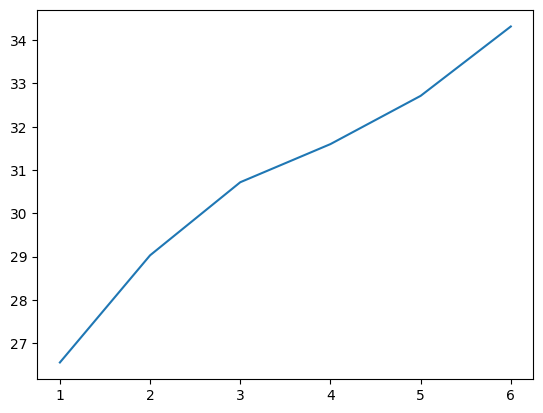

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Entrenamiento
epoch_count = range(1, len(history_ppl) + 1)
sns.lineplot(x=epoch_count,  y=history_ppl)
plt.show()

## Documentación de experimentos: arquitecturas alternativas

Siguiendo la consigna, se proponen y entrenan dos arquitecturas adicionales más robustas que la SimpleRNN utilizada como baseline: una **LSTM** y una **GRU**, ambas precedidas por una capa de `Embedding` entrenable (en lugar de la codificación one-hot utilizada en el modelo base). A continuación se documentan los hiperparámetros probados y los resultados obtenidos en términos de perplejidad de validación.

**Resumen de experimentos:**

| Experimento | Arquitectura | Embedding | Unidades recurrentes | Dropout | Optimizador | Batch size |
|---|---|---|---|---|---|---|
| 1 (baseline) | SimpleRNN | OHE (sin embedding) | 200 | 0.1 / 0.1 | rmsprop | 256 |
| 2 | LSTM | 64 | 256 | 0.2 / 0.2 | rmsprop | 256 |
| 3 | GRU | 64 | 256 | 0.2 / 0.2 | rmsprop | 256 |

Se reutiliza el mismo `PplCallback` (perplejidad + early stopping por `patience`), guardando cada modelo con un nombre distinto (`save_path`) para poder compararlos al finalizar el entrenamiento.

In [29]:
from keras.layers import GRU

### Experimento 2: LSTM con Embedding

In [30]:
embedding_dim = 64

model_lstm = Sequential()
model_lstm.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_shape=(max_context_size,)))
model_lstm.add(LSTM(256, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))
model_lstm.add(Dense(vocab_size, activation='softmax'))
model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model_lstm.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │         4,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 256)       │       328,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100, 69)        │        17,733 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 350,853 (1.34 MB)

 Trainable params: 350,853 (1.34 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history_ppl_lstm = []
hist_lstm = model_lstm.fit(
    X, y,
    epochs=20,
    callbacks=[PplCallback(tokenized_sentences_val, history_ppl_lstm, save_path='model_lstm.keras')],
    batch_size=256
)

Epoch 1/20
983/983 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - loss: 2.9778
 mean perplexity: 27.14189910888672 

Saved new model!
983/983 ━━━━━━━━━━━━━━━━━━━━ 341s 341ms/step - loss: 2.8972
Epoch 2/20
983/983 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - loss: 2.8093
 mean perplexity: 29.845787048339844 

983/983 ━━━━━━━━━━━━━━━━━━━━ 336s 342ms/step - loss: 2.7918
Epoch 3/20
983/983 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - loss: 2.7436
 mean perplexity: 31.056066513061523 

983/983 ━━━━━━━━━━━━━━━━━━━━ 378s 338ms/step - loss: 2.7295
Epoch 4/20
983/983 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - loss: 2.6893
 mean perplexity: 33.64435958862305 

983/983 ━━━━━━━━━━━━━━━━━━━━ 332s 338ms/step - loss: 2.6774
Epoch 5/20
983/983 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - loss: 2.6439
 mean perplexity: 35.70906448364258 

983/983 ━━━━━━━━━━━━━━━━━━━━ 338s 344ms/step - loss: 2.6340
Epoch 6/20
983/983 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - loss: 2.6055
 mean perplexity: 37.764678955078125 

Stopping training...
983/983 ━━━━━━━━━

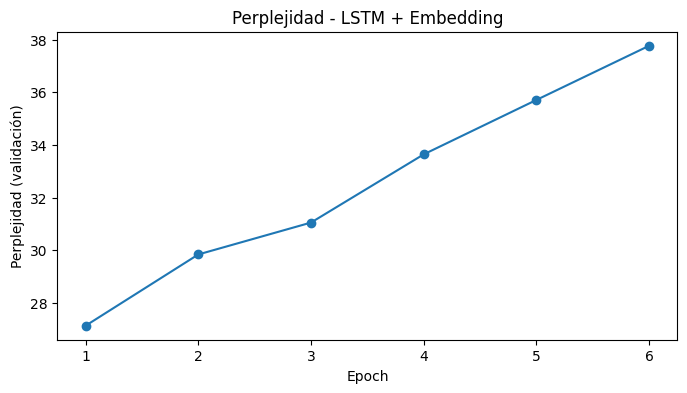

In [32]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(history_ppl_lstm) + 1), history_ppl_lstm, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Perplejidad (validación)')
plt.title('Perplejidad - LSTM + Embedding')
plt.show()

### Experimento 3: GRU con Embedding

In [33]:
model_gru = Sequential()
model_gru.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_shape=(max_context_size,)))
model_gru.add(GRU(256, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))
model_gru.add(Dense(vocab_size, activation='softmax'))
model_gru.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model_gru.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 64)        │         4,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 100, 256)       │       247,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100, 69)        │        17,733 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,445 (1.03 MB)

 Trainable params: 269,445 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
history_ppl_gru = []
hist_gru = model_gru.fit(
    X, y,
    epochs=20,
    callbacks=[PplCallback(tokenized_sentences_val, history_ppl_gru, save_path='model_gru.keras')],
    batch_size=256
)

Epoch 1/20
983/983 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - loss: 2.9636
 mean perplexity: 29.106138229370117 

Saved new model!
983/983 ━━━━━━━━━━━━━━━━━━━━ 308s 311ms/step - loss: 2.8631
Epoch 2/20
983/983 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - loss: 2.7477
 mean perplexity: 32.76797866821289 

983/983 ━━━━━━━━━━━━━━━━━━━━ 309s 315ms/step - loss: 2.7185
Epoch 3/20
983/983 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - loss: 2.6308
 mean perplexity: 38.587215423583984 

983/983 ━━━━━━━━━━━━━━━━━━━━ 305s 310ms/step - loss: 2.6058
Epoch 4/20
983/983 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - loss: 2.5460
 mean perplexity: 42.85914993286133 

983/983 ━━━━━━━━━━━━━━━━━━━━ 325s 313ms/step - loss: 2.5314
Epoch 5/20
983/983 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - loss: 2.4965
 mean perplexity: 45.41165542602539 

983/983 ━━━━━━━━━━━━━━━━━━━━ 306s 311ms/step - loss: 2.4874
Epoch 6/20
983/983 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - loss: 2.4653
 mean perplexity: 48.29990005493164 

Stopping training...
983/983 ━━━━━━━━━━

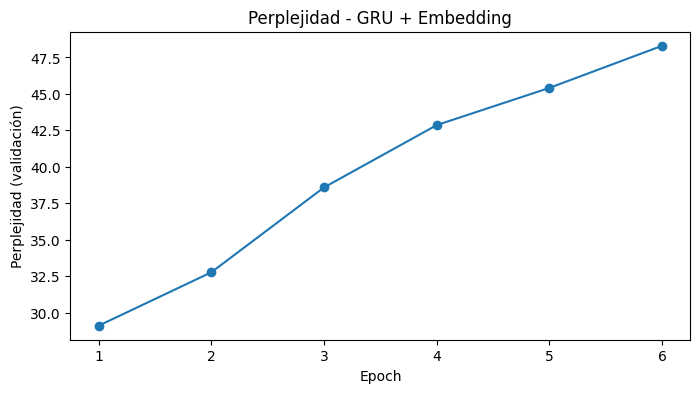

In [35]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(history_ppl_gru) + 1), history_ppl_gru, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Perplejidad (validación)')
plt.title('Perplejidad - GRU + Embedding')
plt.show()

### Comparación de arquitecturas

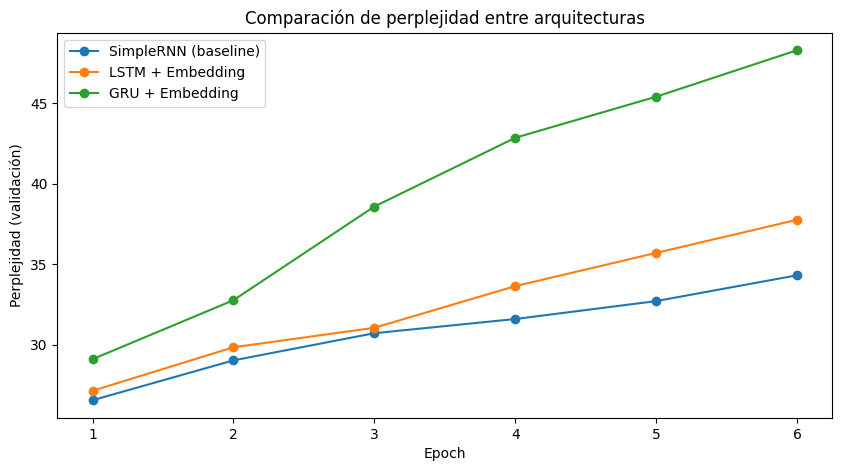

Mejor perplejidad SimpleRNN: 26.56
Mejor perplejidad LSTM: 27.14
Mejor perplejidad GRU: 29.11


In [36]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(history_ppl) + 1), history_ppl, marker='o', label='SimpleRNN (baseline)')
plt.plot(range(1, len(history_ppl_lstm) + 1), history_ppl_lstm, marker='o', label='LSTM + Embedding')
plt.plot(range(1, len(history_ppl_gru) + 1), history_ppl_gru, marker='o', label='GRU + Embedding')
plt.xlabel('Epoch')
plt.ylabel('Perplejidad (validación)')
plt.title('Comparación de perplejidad entre arquitecturas')
plt.legend()
plt.show()

print(f'Mejor perplejidad SimpleRNN: {min(history_ppl):.2f}')
print(f'Mejor perplejidad LSTM: {min(history_ppl_lstm):.2f}')
print(f'Mejor perplejidad GRU: {min(history_ppl_gru):.2f}')

In [37]:
results = {
    'my_model.keras': min(history_ppl),
    'model_lstm.keras': min(history_ppl_lstm),
    'model_gru.keras': min(history_ppl_gru),
}

best_model_path = min(results, key=results.get)
print(f'Mejor modelo: {best_model_path} (perplejidad = {results[best_model_path]:.2f})')

Mejor modelo: my_model.keras (perplejidad = 26.56)


En este experimento, contrariamente a lo esperado, el modelo baseline (SimpleRNN) obtuvo la menor perplejidad de validación (26.56), superando tanto a LSTM (27.14) como a GRU (29.11). Sin embargo, al observar la evolución época a época, se ve que los tres modelos alcanzan su mejor perplejidad en la primera época y luego empeoran progresivamente hasta que el early stopping corta el entrenamiento (patience=5). Esto es un síntoma claro de sobreajuste (overfitting): el loss de entrenamiento sigue bajando en todos los modelos, pero la perplejidad de validación empeora. Como LSTM y GRU tienen muchos más parámetros que la SimpleRNN (por la capa de Embedding y las compuertas internas), son más propensos a sobreajustar rápido con este tamaño de corpus, lo que explica que terminen con peor perplejidad de validación a pesar de ser arquitecturas más expresivas. Para el resto del notebook se utiliza el modelo con menor perplejidad de validación (`best_model_path`), que en este caso resultó ser la SimpleRNN.

In [38]:
# Cargamos el mejor modelo (menor perplejidad de validación) para hacer inferencia
model = keras.models.load_model(best_model_path)


### Predicción del próximo caracter

In [39]:
# Se puede usar gradio para probar el modelo
# Gradio es una herramienta muy útil para crear interfaces para ensayar modelos
# https://gradio.app/

!pip install -q gradio

In [54]:
import gradio as gr

def model_response(human_text):

    # Encodeamos
    encoded = [char2idx[ch] for ch in human_text.lower() ]
    # Si tienen distinto largo
    encoded = pad_sequences([encoded], maxlen=max_context_size, padding='pre')

    # Predicción softmax
    y_hat = np.argmax(model.predict(encoded)[0,-1,:])


    # Debemos buscar en el vocabulario el caracter
    # que corresopnde al indice (y_hat) predicho por le modelo
    out_word = ''
    out_word = idx2char[y_hat]

    # Agrego la palabra a la frase predicha
    return human_text + out_word
    #return repr(human_text) + ' -> ' + repr(out_word)---prueba

iface = gr.Interface(
    fn=model_response,
    inputs=["textbox"],
    outputs="text")

iface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://621403157b62d944d3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://621403157b62d944d3.gradio.live


In [53]:
#print(repr(model_response("the coun")))---prueba
print(repr(model_response("the")))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
'the '


### Generación de secuencias

In [41]:
def generate_seq(model, seed_text, max_length, n_words):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

In [42]:
input_text='the count said'

generate_seq(model, input_text, max_length=max_context_size, n_words=30)

'the count said                              '

###  Beam search y muestreo aleatorio

In [43]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [44]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:,-(len(input)+num_words):]

In [45]:
# predicción con beam search
salidas = beam_search(model,num_beams=10,num_words=20,input="the count said")

In [46]:
salidas[0]

array([48, 23, 44, 59,  0, 62, 24, 33, 48, 59, 18, 31, 58,  4, 62, 59, 59,
       59, 59, 59, 59, 59, 59, 59, 59, 59, 59, 59, 59, 59, 59, 59, 59, 59])

In [47]:
# veamos las salidas
decode(salidas[0])

'the count saido                   '

### Comparación: Greedy Search vs. Beam Search (determinista y estocástico) y efecto de la temperatura

In [48]:
seed = "the count said"
n_words = 40

# Greedy search (equivalente a un beam search con num_beams=1)
greedy_out = beam_search(model, num_beams=1, num_words=n_words, input=seed, mode='det')
print('GREEDY:')
print(decode(greedy_out[0]))
print()

# Beam search determinista
beam_det_out = beam_search(model, num_beams=10, num_words=n_words, input=seed, mode='det')
print('BEAM SEARCH DETERMINISTA (num_beams=10):')
print(decode(beam_det_out[0]))

GREEDY:
the count said                                        

BEAM SEARCH DETERMINISTA (num_beams=10):
the count saido                                       


In [49]:
for temp in [0.2, 0.7, 1.0, 1.5]:
    beam_sto_out = beam_search(model, num_beams=10, num_words=n_words, input=seed, temp=temp, mode='sto')
    print(f'BEAM SEARCH ESTOCÁSTICO (temp={temp}):')
    print(decode(beam_sto_out[0]))
    print()

BEAM SEARCH ESTOCÁSTICO (temp=0.2):
the count saido                                       

BEAM SEARCH ESTOCÁSTICO (temp=0.7):
the count saida   tt    t etn     t    t     t    t s 

BEAM SEARCH ESTOCÁSTICO (temp=1.0):
the count saidi t d   ta n otn.h raott a u de  t   e  

BEAM SEARCH ESTOCÁSTICO (temp=1.5):
the count saide s   t t  me,n auoeh   r n etsetnota tk



**Observaciones:**

- El **greedy search** y el **beam search determinista** quedan atrapados repitiendo espacios en blanco después de las primeras palabras (`"the count said                    "`), un caso claro de bucle de repetición: el modelo encuentra un carácter "seguro" (el espacio) y lo repite indefinidamente al no explorar otras alternativas.
- Con **temperatura baja** (0.2) el muestreo estocástico se comporta igual que el determinista, cayendo en el mismo bucle de espacios.
- A partir de **temperatura 0.7** el modelo logra escapar del bucle de repetición, pero el texto generado se vuelve prácticamente ilegible (combinaciones de letras sueltas sin formar palabras reales), y esto empeora aún más con temperaturas de 1.0 y 1.5.
- A diferencia de lo esperado teóricamente (donde suele existir una temperatura intermedia que balancea coherencia y diversidad), en este experimento no se observa una "zona coherente" clara: el modelo pasa directamente de repetir un único carácter a generar texto desordenado. Esto es consistente con lo observado en la sección anterior: el entrenamiento se cortó temprano por sobreajuste (early stopping en la época 6, con perplejidad de validación relativamente alta, ~26-30), por lo que el modelo no llegó a aprender patrones de palabras lo suficientemente robustos como para generar texto coherente en un régimen de mayor diversidad.

## Conclusiones

- Se entrenó un modelo de lenguaje a nivel de caracteres sobre el corpus de *Dracula* de Bram Stoker (el mismo corpus reutilizado del Desafío 2), comparando tres arquitecturas recurrentes: SimpleRNN (baseline), LSTM y GRU, estas dos últimas con una capa de `Embedding` entrenable.
- El tamaño de contexto (`max_context_size`) se eligió a partir de un análisis de la distribución de longitudes de oraciones del corpus, en lugar de fijarlo de forma arbitraria.


- Contrariamente a lo esperado, la SimpleRNN (baseline) obtuvo la menor perplejidad de validación (26.56) frente a LSTM (27.14) y GRU (29.11). Los tres modelos mostraron signos de sobreajuste (mejor perplejidad en la primera época, empeorando luego), siendo más marcado en las arquitecturas con más parámetros (LSTM y GRU), lo que explica el resultado.



- Se implementaron y compararon estrategias de generación de secuencias: greedy search, beam search determinista y beam search estocástico, analizando el efecto de la temperatura sobre la calidad y diversidad del texto generado.



- El muestreo estocástico permitió escapar del bucle de repetición de espacios en blanco típico del greedy/beam determinista, pero en este experimento no se logró un punto intermedio de temperatura que generara texto coherente: al aumentar la temperatura, el modelo pasa directamente de repetir un carácter a producir texto desordenado, reflejo de que el entrenamiento se cortó temprano por sobreajuste.